In [1]:
import pandas as pd
import numpy as np

# 1. Load the Wine Quality Dataset (Red Wine)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# 2. Explore dataset properties
print(f"Number of Records (Rows): {df.shape[0]}")
print(f"Number of Features: {df.shape[1] - 1}")  # Exclude target
print(f"Feature Names: {list(df.columns[:-1])}")
print(f"Target Variable: '{df.columns[-1]}'")
print("\nData Types:\n", df.dtypes)
print("\nMissing Values per Feature:\n", df.isnull().sum())
print(f"\nNumber of Duplicate Records: {df.duplicated().sum()}")

Number of Records (Rows): 1599
Number of Features: 11
Feature Names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Target Variable: 'quality'

Data Types:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing Values per Feature:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
qual

In [2]:
# Generate summary statistics for numerical features
stats = df.describe().T[['mean', 'std', 'min', '50%', 'max']]
stats.rename(columns={'50%': 'median'}, inplace=True)
print(stats)

                           mean        std      min    median        max
fixed acidity          8.319637   1.741096  4.60000   7.90000   15.90000
volatile acidity       0.527821   0.179060  0.12000   0.52000    1.58000
citric acid            0.270976   0.194801  0.00000   0.26000    1.00000
residual sugar         2.538806   1.409928  0.90000   2.20000   15.50000
chlorides              0.087467   0.047065  0.01200   0.07900    0.61100
free sulfur dioxide   15.874922  10.460157  1.00000  14.00000   72.00000
total sulfur dioxide  46.467792  32.895324  6.00000  38.00000  289.00000
density                0.996747   0.001887  0.99007   0.99675    1.00369
pH                     3.311113   0.154386  2.74000   3.31000    4.01000
sulphates              0.658149   0.169507  0.33000   0.62000    2.00000
alcohol               10.422983   1.065668  8.40000  10.20000   14.90000
quality                5.636023   0.807569  3.00000   6.00000    8.00000


In [3]:
# Check for missing values and handle if present (impute using column median)
if df.isnull().sum().sum() > 0:
    df = df.fillna(df.median())

# Handle duplicates by removing them
df_cleaned = df.drop_duplicates().copy()

# Verify the cleaned dataset
print(f"Original shape: {df.shape}")
print(f"Cleaned shape after dropping duplicates: {df_cleaned.shape}")
print(f"Remaining missing values: {df_cleaned.isnull().sum().sum()}")

Original shape: (1599, 12)
Cleaned shape after dropping duplicates: (1359, 12)
Remaining missing values: 0


In [4]:
# Input features (X): Chemical properties of wine
X = df_cleaned.drop(columns=['quality'])

# Target variable (y): Wine quality score
y = df_cleaned['quality']

print(f"Feature Matrix Shape (X): {X.shape}")
print(f"Target Vector Shape (y): {y.shape}")

Feature Matrix Shape (X): (1359, 11)
Target Vector Shape (y): (1359,)


In [5]:
# Calculate minimum, maximum, and range for each feature
feature_ranges = pd.DataFrame({
    'Min': X.min(),
    'Max': X.max(),
    'Range (Max - Min)': X.max() - X.min()
}, index=X.columns)

print(feature_ranges)

                          Min        Max  Range (Max - Min)
fixed acidity         4.60000   15.90000           11.30000
volatile acidity      0.12000    1.58000            1.46000
citric acid           0.00000    1.00000            1.00000
residual sugar        0.90000   15.50000           14.60000
chlorides             0.01200    0.61100            0.59900
free sulfur dioxide   1.00000   72.00000           71.00000
total sulfur dioxide  6.00000  289.00000          283.00000
density               0.99007    1.00369            0.01362
pH                    2.74000    4.01000            1.27000
sulphates             0.33000    2.00000            1.67000
alcohol               8.40000   14.90000            6.50000


 Explanation of Feature Scaling NecessityScale Disparity: Features operate on vastly different scales. For instance, density ranges from 0.990 to 1.004 (range $\approx 0.014$), whereas total sulfur dioxide ranges from 6 to 289 (range $= 283$).Model Bias: Distance-based algorithms (such as $k$-Nearest Neighbors, Support Vector Machines) and gradient-descent optimizers (such as Linear/Logistic Regression and Neural Networks) will give disproportionately higher weight to features with larger magnitude ranges (total sulfur dioxide), misrepresenting their true predictive importance.Convergence Speed: Scaling features to uniform scales speeds up optimization convergence in gradient-based algorithms.

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Initialize scalers
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Apply transformations
X_std = pd.DataFrame(std_scaler.fit_transform(X), columns=X.columns)
X_minmax = pd.DataFrame(minmax_scaler.fit_transform(X), columns=X.columns)

# Compare raw vs transformed values for 'total sulfur dioxide' and 'alcohol'
comparison_df = pd.DataFrame({
    'Original (Total SO2)': X['total sulfur dioxide'].head(3),
    'StandardScaler (Total SO2)': X_std['total sulfur dioxide'].head(3),
    'MinMaxScaler (Total SO2)': X_minmax['total sulfur dioxide'].head(3),
    'Original (Alcohol)': X['alcohol'].head(3),
    'StandardScaler (Alcohol)': X_std['alcohol'].head(3),
    'MinMaxScaler (Alcohol)': X_minmax['alcohol'].head(3)
})

print(comparison_df.round(3))

   Original (Total SO2)  StandardScaler (Total SO2)  MinMaxScaler (Total SO2)  \
0                  34.0                      -0.384                     0.099   
1                  67.0                       0.604                     0.216   
2                  54.0                       0.215                     0.170   

   Original (Alcohol)  StandardScaler (Alcohol)  MinMaxScaler (Alcohol)  
0                 9.4                    -0.954                   0.154  
1                 9.8                    -0.585                   0.215  
2                 9.8                    -0.585                   0.215  


In [7]:
from sklearn.model_selection import train_test_split

# Split dataset into 80% training set and 20% testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Maintain class balance of target 'quality'
)

In [8]:
from sklearn.pipeline import Pipeline

# Define numerical preprocessing pipeline
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# CRITICAL: Fit ONLY on training data, transform both train and test sets
X_train_processed = num_pipeline.fit_transform(X_train)
X_test_processed = num_pipeline.transform(X_test)

In [9]:
print("--- DATASET SHAPES ---")
print(f"Original Cleaned Dataset Shape: {df_cleaned.shape}")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"Processed X_train Matrix Shape: {X_train_processed.shape}")
print(f"Processed X_test Matrix Shape: {X_test_processed.shape}")

print("\n--- SAMPLE PROCESSED TRAINING DATA (First 2 Rows) ---")
print(np.round(X_train_processed[:2], 3))

print("\n--- SAMPLE PROCESSED TESTING DATA (First 2 Rows) ---")
print(np.round(X_test_processed[:2], 3))

--- DATASET SHAPES ---
Original Cleaned Dataset Shape: (1359, 12)
X_train Shape: (1087, 11)
X_test Shape: (272, 11)
Processed X_train Matrix Shape: (1087, 11)
Processed X_test Matrix Shape: (272, 11)

--- SAMPLE PROCESSED TRAINING DATA (First 2 Rows) ---
[[-0.632 -0.172 -0.473 -0.322 -0.342 -0.377 -0.476  0.472  1.331  0.378
  -0.77 ]
 [-0.743  0.259  0.036  1.684 -0.048 -0.377  0.631 -0.195  0.072  0.26
   0.507]]

--- SAMPLE PROCESSED TESTING DATA (First 2 Rows) ---
[[-0.017  0.366 -0.117 -0.248  0.645 -0.66  -0.272 -0.284 -0.999 -0.743
  -0.587]
 [-0.743 -0.55  -1.287 -0.47  -0.153 -0.095 -0.563 -0.93   0.261  0.909
   0.143]]


C:\Users\sys\AppData\Local\Temp\ipykernel_4432\1268530262.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(acidity_by_quality, labels=quality_levels)


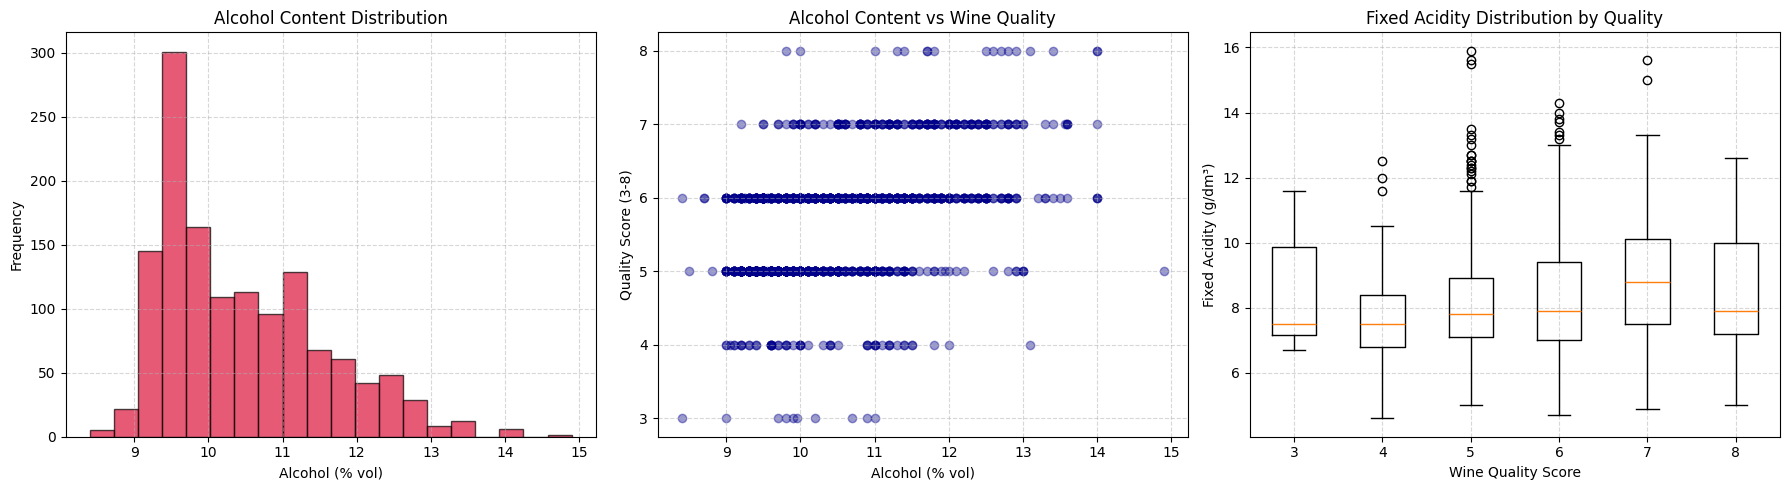

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Feature Distribution (Alcohol)
axes[0].hist(df_cleaned['alcohol'], bins=20, color='crimson', edgecolor='black', alpha=0.7)
axes[0].set_title('Alcohol Content Distribution')
axes[0].set_xlabel('Alcohol (% vol)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Correlation between Alcohol and Quality
axes[1].scatter(df_cleaned['alcohol'], df_cleaned['quality'], alpha=0.4, color='darkblue')
axes[1].set_title('Alcohol Content vs Wine Quality')
axes[1].set_xlabel('Alcohol (% vol)')
axes[1].set_ylabel('Quality Score (3-8)')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Plot 3: Fixed Acidity by Wine Quality Score
quality_levels = sorted(df_cleaned['quality'].unique())
acidity_by_quality = [df_cleaned[df_cleaned['quality'] == q]['fixed acidity'] for q in quality_levels]

axes[2].boxplot(acidity_by_quality, labels=quality_levels)
axes[2].set_title('Fixed Acidity Distribution by Quality')
axes[2].set_xlabel('Wine Quality Score')
axes[2].set_ylabel('Fixed Acidity (g/dm³)')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Analysis & Evaluation of Preprocessing Workflow
Which Features Required Preprocessing:

Features with extreme magnitude variance required scaling (total sulfur dioxide, free sulfur dioxide, and residual sugar vs. density and pH).

Skewed features benefited from standardization to center values around zero.

Why Scaling Was Applied:

To prevent high-magnitude attributes from dominating objective functions, optimization procedures, and distance calculations during algorithm execution.

How Preprocessing Changes Feature Representation:

StandardScaler transforms features into standard Normal distributions with mean μ=0 and standard deviation σ=1, preserving structural variance while standardizing axes.

MinMaxScaler bounds values to a fixed interval [0,1], preserving exact relative distances between data points.

Importance of Train-Test Splitting:

Splitting allows evaluating Machine Learning models on unseen data, serving as a check against overfitting and providing realistic estimation of generalization ability.

Machine Learning Readiness:

The final output matrices (X_train_processed, X_test_processed, y_train, y_test) are cleaned, scaled, leakage-free, and directly formatted for estimator algorithms (e.g., Random Forest, Support Vector Classifiers, Ridge Regression).